Marcos Lopes (PECE/USP) -- 2025

In [1]:
def ler(nome_arquivo) -> str:
    with open(nome_arquivo, 'r', encoding='utf-8') as arquivo:
        return arquivo.read()


In [2]:
# from google.colab import files

# uploaded = files.upload()


In [3]:
texto = ler('Guarani.txt')


# Concordanciador

Um concordanciador é um sistema de exibição de contextos (vizinhança) à esquerda e à direita de um termo-alvo. O contexto deve ser previamente delimitado por uma janela de $k$ caracteres.

É fácil implementar um concordanciador através do método str.find() do Python.

In [4]:
# Exemplos do método str.find()

print('abcd'.find('b'))  # Procura uma substring a partir da posição 0
print('abcd-abcd'.find('b', 2))  # Procura uma substring a partir da posição indicada (3)
print('abcd'.find('x'))  # Se a substring não for encontrada, o método retorna -1


1
6
-1


In [5]:
# Criação de um concordanciador simples

def concordancia(corpus: str, alvo: str, janela: int = 40) -> list:
    corpus = corpus.replace('\n', ' ')
    bingo = list()
    tam_alvo = len(alvo)
    pos = corpus.find(alvo)

    while pos >= 0:
        bingo.append(corpus[pos - janela : pos + janela + tam_alvo])
        pos = corpus.find(alvo, pos + 1)

    return bingo


In [6]:
concordancia(texto, 'índio ', 40)


['mem civilizado a astúcia e agilidade do índio de quem haviam aprendido; eram uma espéc',
 'ho tronco decepado pelo raio, via-se um índio na flor da idade. Uma simples túnica de ',
 'sse fazer a pontaria entre as folhas, o índio bateu com o pé no chão em sinal de impac',
 'gradecerá. Em resposta a esta ameaça, o índio empurrou desdenhosamente com a ponta do ',
 'u rapidamente, em um segundo, sem que o índio deixasse um só instante com os olhos o i',
 ' da fera; a pequena seta despedida pelo índio se cravara na orelha, e uma segunda, aço',
 'uma lata de morte a que ia se travar; o índio o sabia, e esperou tranqüilamente, como ',
 ' força e agilidade. Como a princípio, o índio havia dobrado um pouco os joelhos, e seg',
 'ando o seu pêlo vermelho e afogueado. O índio saltou sobre o arco, e abateu-a daí a al',
 'exalou-se num gemido surdo e abafado. O índio sorria, vendo os esforços da fera para a',
 ' são a sua arma mais terrível. Quando o índio satisfez o prazer de contemplar o seu ca',

# Estatísticas descritivas com Pandas e Pontuação-Padrão (z-score)

Vamos relembrar rapidamente alguns objetos e métodos do Pandas. Trata-se de um módulo externo usado para análises de dados estruturados (tabelas).

O módulo tem como objeto principal o DataFrame, que nada mais é que uma tabela indexada (isto é, contando as linhas a partir do 0).

In [7]:
# Importação do módulo e criação de um DataFrame simples

import pandas as pd


In [8]:
# Exemplos para relembrar...

df = pd.DataFrame({'a': [1, 2], 'b': [10, 20]})
df


,a,b
0,1,10
1,2,20


In [9]:
# Para filtrar dados: método query

df.query('a >= 2')


,a,b
1,2,20


In [10]:
# Para acrescentar novas colunas ao df (coluna 'c', no caso)

df['c'] = df['b'] * 10
df


,a,b,c
0,1,10,100
1,2,20,200


**Exemplo de aplicação**

Vamos usar o Pandas para mostrar algumas estatísticas a respeito do nosso Guarani.

In [11]:
# Vamos usar o tokenizador do NLTK
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize, word_tokenize


def tokenizar(txt: str) -> list:
    return word_tokenize(txt, language='portuguese')


# Vamos usar também nossa função de faxina rápida
def limpar(lista: list) -> list:
    return [i.lower() for i in lista if i.isalpha()]


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\knd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
# Tokenização de palavras e pontuação

palavras = limpar(tokenizar(texto))


In [13]:
# Conferindo...

palavras[:10]


['o',
 'guarani',
 'de',
 'josé',
 'de',
 'alencar',
 'fonte',
 'alencar',
 'josé',
 'de']

In [14]:
# Agora, vamos gerar o vocabulário

vocab = set(palavras)


In [15]:
# Vamos criar uma lista de tuplas (palavra, tamanho da palavra).

tamanhos_palavras = [(i, len(i)) for i in vocab]
tamanhos_palavras[:20]


[('interior', 8),
 ('descobriram', 11),
 ('reconhecendo', 12),
 ('inutilizaria', 12),
 ('entrechocavam', 13),
 ('verdadeira', 10),
 ('resolutos', 9),
 ('bandeira', 8),
 ('procedeis', 9),
 ('resinas', 7),
 ('anuviasse', 9),
 ('imitando', 8),
 ('escrava', 7),
 ('goelas', 6),
 ('protetor', 8),
 ('crastas', 7),
 ('saúde', 5),
 ('rude', 4),
 ('desconfiança', 12),
 ('acompanhe', 9)]

In [16]:
# Essas tuplas vão para um DataFrame

df = pd.DataFrame(tamanhos_palavras, columns=['palavra', 'tamanho'])
print(df.head())


         palavra  tamanho
0       interior        8
1    descobriram       11
2   reconhecendo       12
3   inutilizaria       12
4  entrechocavam       13


In [17]:
# Já podemos gerar algumas estatísticas.
# Primeiro, uma sumarização geral dos dados:

df.describe()


,tamanho
count,10692.000000
mean,7.571455
std,2.237728
min,1.000000
25%,6.000000
50%,7.000000
75%,9.000000
max,18.000000


In [18]:
# É simples gerar estatísticas das séries de dados (colunas).
# Aqui vai a mediana.
# Lembre-se: se a mediana for menor que a média, isso signfica que valores altos
# (outliers) estão puxando a média para cima.

df['tamanho'].median()


np.float64(7.0)

In [19]:
# Com o Pandas, é muito rápido localizar os Hápax Legômena (e excluí-los, se necessário)

# Primeiro, cria-se um DataFrame com as palavras isoladas
df_tokens = pd.DataFrame()
df_tokens['palavra'] = palavras
df_tokens.head()


,palavra
0,o
1,guarani
2,de
3,josé
4,de


In [20]:
# Em seguida, adiciona-se uma série de dados com as contagens

cont = df_tokens['palavra'].value_counts()
df_cont = pd.DataFrame({'palavras': cont.index, 'ocorrências': cont.values})
df_cont.head()


,palavras,ocorrências
0,a,4392
1,que,4283
2,o,3899
3,de,3867
4,e,3587


In [21]:
# Agora, é só consultar quais aquelas com uma única ocorrência
# Com o mesmo procedimento, é possível excluir outros números pequenos
# de ocorrência, até chegar a uma "faixa de relevância" (ocorrências > 5, por ex.)

df_cont.query('ocorrências == 1')


,palavras,ocorrências
5410,purpúreas,1
5411,ática,1
5412,jacarandás,1
5413,soberbos,1
5414,crescia,1
...,...,...
10687,estupenda,1
10688,fauce,1
10689,leque,1
10690,virtual,1


In [22]:
# Para a Pontuação Média, usaremos o módulo scipy
from scipy import stats as st

print(st.zscore(df.tamanho))


[0.19151778 1.53222586 1.97912856 ... 0.63842048 0.63842048 0.19151778]


In [23]:
# Cálculo da pontuação média (z-score) dos tamanhos

df['z'] = st.zscore(df['tamanho'])
df


,palavra,tamanho,z
0,interior,8,0.191518
1,descobriram,11,1.532226
2,reconhecendo,12,1.979129
3,inutilizaria,12,1.979129
4,entrechocavam,13,2.426031
...,...,...,...
10687,famoso,6,-0.702288
10688,tio,3,-2.042996
10689,perfeição,9,0.638420
10690,tanchagem,9,0.638420


In [24]:
# Quais a porcentagem de palavras grandes (z > 3) no corpus?

palavronas = df.query('z > 3')
print(f'{len(palavronas) / len(df):.2%}')


0.34%


In [25]:
# z > 4 é o final da curva, mesmo. Pouquíssimas palavras.

print(df.query('z > 4'))


                 palavra  tamanho         z
3007   irremediavelmente       17  4.213642
5617   involuntariamente       17  4.213642
6531  imperceptivelmente       18  4.660545
8762   irremissivelmente       17  4.213642
8926  perpendicularmente       18  4.660545
9019  incontestavelmente       18  4.660545


In [26]:
# Intervalos (baldes)

baldes = df.tamanho.value_counts(normalize=True, bins=6)
print(baldes)


(6.667, 9.5]        0.478769
(3.833, 6.667]      0.308455
(9.5, 12.333]       0.170221
(0.982, 3.833]      0.023195
(12.333, 15.167]    0.018238
(15.167, 18.0]      0.001122
Name: proportion, dtype: float64


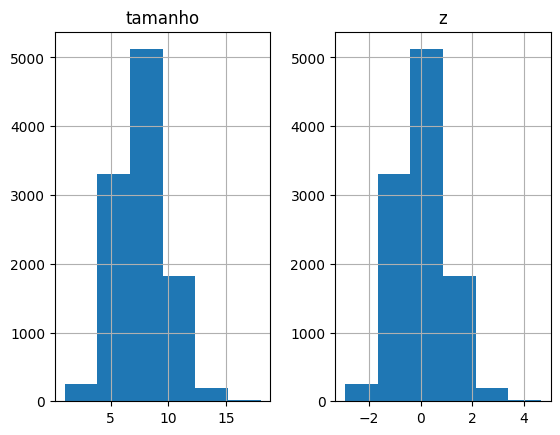

In [27]:
# Geração de histogramas para exibição da distribuição

hist = df.hist(bins=6)


# Exercício

Repita os procedimentos de tokenização e cálculo da Pontuação Média para o tamanho das sentenças. Dica: use o tokenizador de sentenças do NLTK.


---


**Pode ser útil...**

In [28]:
# Tokenização de sentenças

def tokenizar_sentencas(txt: str) -> list:
    txt = txt.replace('\n', ' ')
    return sent_tokenize(txt, language='portuguese')


In [29]:
# Método tolist(): gera uma lista com os resultados

df.query('z > 4').values.tolist()[-1]


['incontestavelmente', 18, 4.660544718488665]

In [ ]:
# Método str.contains(): Busca uma substring na coluna indicada

df_x = df[df['sent'].str.contains('Cecília') == True]
df_x



---


# Resolucao

In [35]:
sentences = tokenizar_sentencas(texto)
sentences[:3]


['O Guarani, de José de Alencar Fonte: ALENCAR, José de.',
 'O guarani.',
 '20a ed., São Paulo: Ática, 1996 (Bom Livro).']

In [36]:
df = pd.DataFrame([[sentence, len(sentence)] for sentence in sentences], columns=['sentence', 'size']) 
df.head()


,sentence,size
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ...",54
1,O guarani.,10
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro).",44
3,Texto proveniente de: A Biblioteca Virtual do ...,196
4,Este material pode ser redistribuído livrement...,120


In [39]:
df.describe()


,size
count,5778.000000
mean,106.943233
std,81.664730
min,2.000000
25%,31.000000
50%,95.000000
75%,167.000000
max,819.000000


In [42]:
df['z'] = st.zscore(df['size'])


In [44]:
df.head()


,sentence,size,z
0,"O Guarani, de José de Alencar Fonte: ALENCAR, ...",54,-0.648356
1,O guarani.,10,-1.187191
2,"20a ed., São Paulo: Ática, 1996 (Bom Livro).",44,-0.770818
3,Texto proveniente de: A Biblioteca Virtual do ...,196,1.090611
4,Este material pode ser redistribuído livrement...,120,0.159896


In [47]:
df.query('z>4')


,sentence,size,z
842,"O peixe que beijava a flor da água, e que podi...",496,4.764486
1529,“De quantos crimes já não tinha sido causa ess...,479,4.556299
1558,Quebrou com os dentes o selo do papel; chegand...,819,8.720024
1787,"Um ano havia que esperava, e como ele dizia, e...",453,4.237897
1966,"O moço, apesar de preocupado, tinha o hábito d...",621,6.295267
2083,Quem conhece a vegetação de nossa terra desde ...,495,4.752239
4268,As almas grandes têm esse privilégio; suas açõ...,439,4.066450


In [50]:
df.query('z<-1')


,sentence,size,z
1,O guarani.,10,-1.187191
17,Adeus.,6,-1.236176
18,"Minas, 12 de dezembro.",22,-1.040236
82,Eu o juro!,10,-1.187191
115,"— Vamos, rapazes!",17,-1.101467
...,...,...,...
5736,— Tu não sabes?,15,-1.125960
5751,“Todos morreram.,16,-1.113713
5758,Peri!...,8,-1.211683
5767,— Sim?...,9,-1.199437
